# Análisis de resultados — STGNN Temperatura DMQ
**Modelo:** A3T-GCN (comparación con DCRNN cuando esté disponible)
**Escenarios:** corto (h=3), medio (h=48), largo (h=72)

Este notebook produce tablas, gráficas comparativas, análisis de error por
estación y un *forecasting* sobre marzo 2026. Ajusta las rutas en la primera
celda si tu estructura de carpetas difiere.


In [1]:
%matplotlib inline
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# fallback de display para correr también fuera de Jupyter
try:
    display
except NameError:
    def display(x): print(x)

# ------------------- RUTAS (ajusta si difiere) -------------------
ART_DIR   = "artefactos"
RES_A3T   = "resultados/a3tgcn"
RES_DCRNN = "resultados/dcrnn"          # opcional (si ya corriste DCRNN)
FIG_DIR   = "resultados/figuras"
os.makedirs(FIG_DIR, exist_ok=True)

ESCENARIOS = ["corto", "medio", "largo"]
COLORS = {"corto": "#2a9d8f", "medio": "#e9a12a", "largo": "#e76f51"}
ESTACION_FORECAST = "Belisario"         # estación para el forecasting detallado

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})


## 1. Carga de artefactos, métricas y utilidades

In [2]:
def cargar_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

met_a3t   = cargar_json(os.path.join(RES_A3T, "metricas_a3tgcn.json"))
tiempos   = np.load(os.path.join(ART_DIR, "tiempos.npy"))
splits    = cargar_json(os.path.join(ART_DIR, "splits.json"))
estaciones = cargar_json(os.path.join(ART_DIR, "station_order.json"))
test_a, test_b = splits["test"]

print("Estaciones:", estaciones)
print("Ventana TEST:", str(tiempos[test_a])[:16], "->", str(tiempos[test_b-1])[:16],
      f"({test_b-test_a:,} pasos)")

def cargar_preds(res_dir, prefijo, esc, met):
    """Devuelve (pred, true, timestamps, L, h). pred/true en °C, forma (S, N)."""
    h = met[esc]["config"]["horizon"]; L = met[esc]["config"]["seq_len"]
    tag = f"{prefijo}_{esc}_h{h}"
    pred = np.load(os.path.join(res_dir, f"{tag}_pred_test.npy"))
    true = np.load(os.path.join(res_dir, f"{tag}_true_test.npy"))
    S = pred.shape[0]
    start = test_a + L + h - 1          # índice global del 1er target de test
    ts = tiempos[start:start + S]
    return pred, true, ts, L, h

PREDS_OK = all(
    os.path.exists(os.path.join(RES_A3T,
        f"a3tgcn_{e}_h{met_a3t[e]['config']['horizon']}_pred_test.npy"))
    for e in ESCENARIOS)
print("Arrays de predicción disponibles:", PREDS_OK)


Estaciones: ['Belisario', 'Carapungo', 'Cotocollao', 'ElCamal', 'LosChillos', 'Tumbaco']
Ventana TEST: 2024-01-01T00:00 -> 2026-03-31T23:00 (19,704 pasos)
Arrays de predicción disponibles: True


## 2. Tabla de métricas globales (A3T-GCN)

In [3]:
filas = []
for esc in ESCENARIOS:
    g = met_a3t[esc]["global"]; c = met_a3t[esc]["config"]
    filas.append({"escenario": esc, "horizonte_h": c["horizon"], "seq_len": c["seq_len"],
                  "MAE (°C)": g["MAE"], "RMSE (°C)": g["RMSE"], "R²": g["R2"],
                  "MAPE (%)": g["MAPE"], "epochs": met_a3t[esc]["epochs_corridos"]})
tabla_global = pd.DataFrame(filas).set_index("escenario").round(4)
tabla_global.to_csv(os.path.join(FIG_DIR, "tabla_global_a3tgcn.csv"))
display(tabla_global)


,horizonte_h,seq_len,MAE (°C),RMSE (°C),R²,MAPE (%),epochs
escenario,,,,,,,
corto,3,24,0.7233,1.0166,0.9147,4.6897,40
medio,48,96,1.0484,1.4110,0.8360,6.9318,18
largo,72,168,1.1085,1.4758,0.8207,7.2876,12


## 3. Métricas por estación

In [4]:
def tabla_por_estacion(met, metrica):
    d = {esc: {est: met[esc]["por_estacion"][est][metrica] for est in estaciones}
         for esc in ESCENARIOS}
    return pd.DataFrame(d).round(4)

tabla_mae_est = tabla_por_estacion(met_a3t, "MAE")
tabla_r2_est  = tabla_por_estacion(met_a3t, "R2")
print("MAE por estación (°C):"); display(tabla_mae_est)
print("\nR² por estación:");     display(tabla_r2_est)
tabla_mae_est.to_csv(os.path.join(FIG_DIR, "mae_por_estacion_a3tgcn.csv"))


MAE por estación (°C):


,corto,medio,largo
Belisario,0.7016,1.0412,1.1049
Carapungo,0.7187,0.9932,1.0557
Cotocollao,0.6455,0.9180,0.9663
ElCamal,0.6536,0.9528,1.0083
LosChillos,0.8425,1.2103,1.2926
Tumbaco,0.7782,1.1751,1.2233



R² por estación:


,corto,medio,largo
Belisario,0.9001,0.7988,0.7799
Carapungo,0.9047,0.8285,0.8087
Cotocollao,0.9057,0.8283,0.8137
ElCamal,0.8903,0.7917,0.7737
LosChillos,0.9053,0.8243,0.8053
Tumbaco,0.9195,0.8283,0.8162


## 4. Curva de degradación (error vs horizonte)

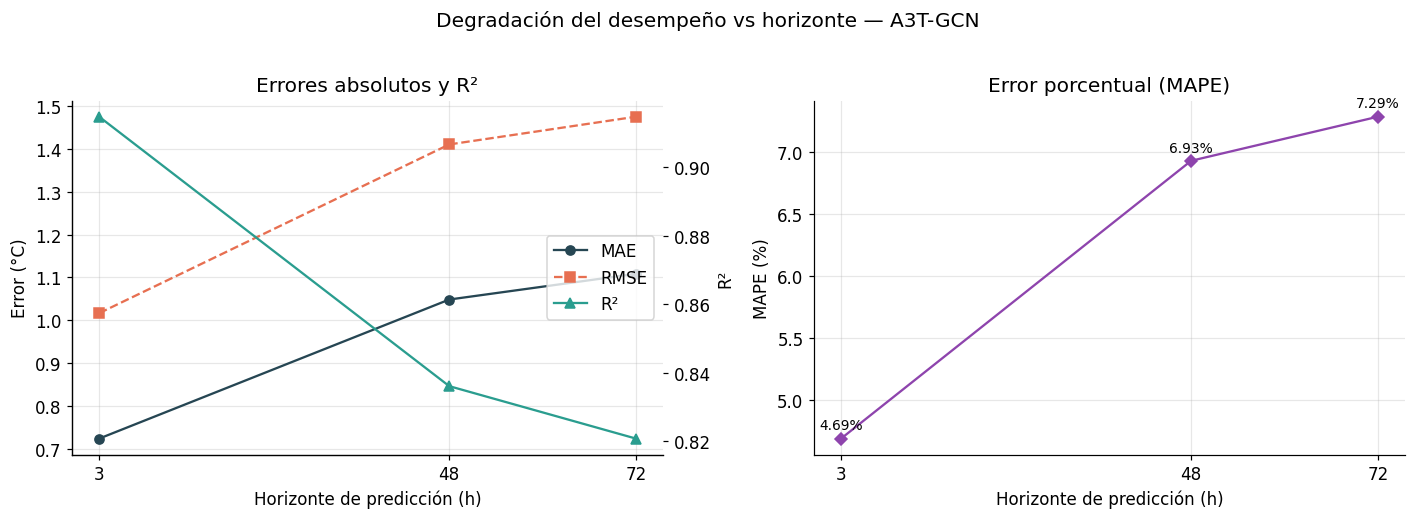

In [5]:
hs   = [met_a3t[e]["config"]["horizon"] for e in ESCENARIOS]
mae  = [met_a3t[e]["global"]["MAE"]  for e in ESCENARIOS]
rmse = [met_a3t[e]["global"]["RMSE"] for e in ESCENARIOS]
r2   = [met_a3t[e]["global"]["R2"]   for e in ESCENARIOS]
mape = [met_a3t[e]["global"]["MAPE"] for e in ESCENARIOS]

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# --- Panel A: errores absolutos (°C) + R² ---
axA.plot(hs, mae,  "o-", color="#264653", label="MAE")
axA.plot(hs, rmse, "s--", color="#e76f51", label="RMSE")
axA.set_xlabel("Horizonte de predicción (h)"); axA.set_ylabel("Error (°C)")
axA.set_xticks(hs)
axA2 = axA.twinx(); axA2.plot(hs, r2, "^-", color="#2a9d8f", label="R²")
axA2.set_ylabel("R²"); axA2.grid(False)
h1, l1 = axA.get_legend_handles_labels(); h2, l2 = axA2.get_legend_handles_labels()
axA.legend(h1 + h2, l1 + l2, loc="center right")
axA.set_title("Errores absolutos y R²")

# --- Panel B: error porcentual (MAPE) ---
axB.plot(hs, mape, "D-", color="#8e44ad", label="MAPE")
for x, y in zip(hs, mape):
    axB.text(x, y + 0.05, f"{y:.2f}%", ha="center", va="bottom", fontsize=9)
axB.set_xlabel("Horizonte de predicción (h)"); axB.set_ylabel("MAPE (%)")
axB.set_xticks(hs); axB.set_title("Error porcentual (MAPE)")

plt.suptitle("Degradación del desempeño vs horizonte — A3T-GCN", y=1.02)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "degradacion.png"), bbox_inches="tight")
plt.show()


## 5. Barras comparativas de error por escenario

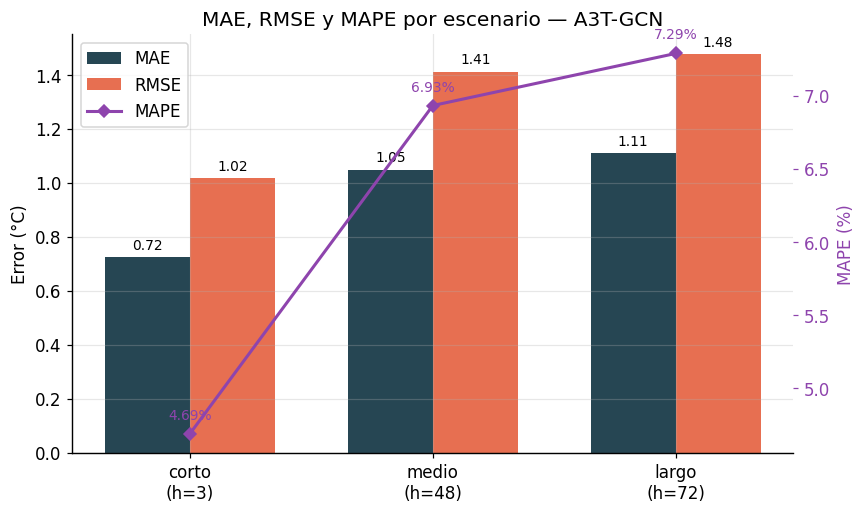

In [6]:
x = np.arange(len(ESCENARIOS)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(x - w/2, mae,  w, label="MAE",  color="#264653")
ax.bar(x + w/2, rmse, w, label="RMSE", color="#e76f51")
ax.set_xticks(x)
ax.set_xticklabels([f"{e}\n(h={met_a3t[e]['config']['horizon']})" for e in ESCENARIOS])
ax.set_ylabel("Error (°C)"); ax.set_title("MAE, RMSE y MAPE por escenario — A3T-GCN")
for i, (m, r) in enumerate(zip(mae, rmse)):
    ax.text(i - w/2, m + 0.02, f"{m:.2f}", ha="center", va="bottom", fontsize=9)
    ax.text(i + w/2, r + 0.02, f"{r:.2f}", ha="center", va="bottom", fontsize=9)

# MAPE como línea en eje secundario
ax2 = ax.twinx()
ax2.plot(x, mape, "D-", color="#8e44ad", label="MAPE", lw=2)
ax2.set_ylabel("MAPE (%)", color="#8e44ad"); ax2.grid(False)
ax2.tick_params(axis="y", colors="#8e44ad")
for xi, mp in zip(x, mape):
    ax2.text(xi, mp + 0.08, f"{mp:.2f}%", ha="center", va="bottom",
             color="#8e44ad", fontsize=9)

h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "barras_error.png"), bbox_inches="tight")
plt.show()


## 6. Heatmap de MAE por estación y horizonte

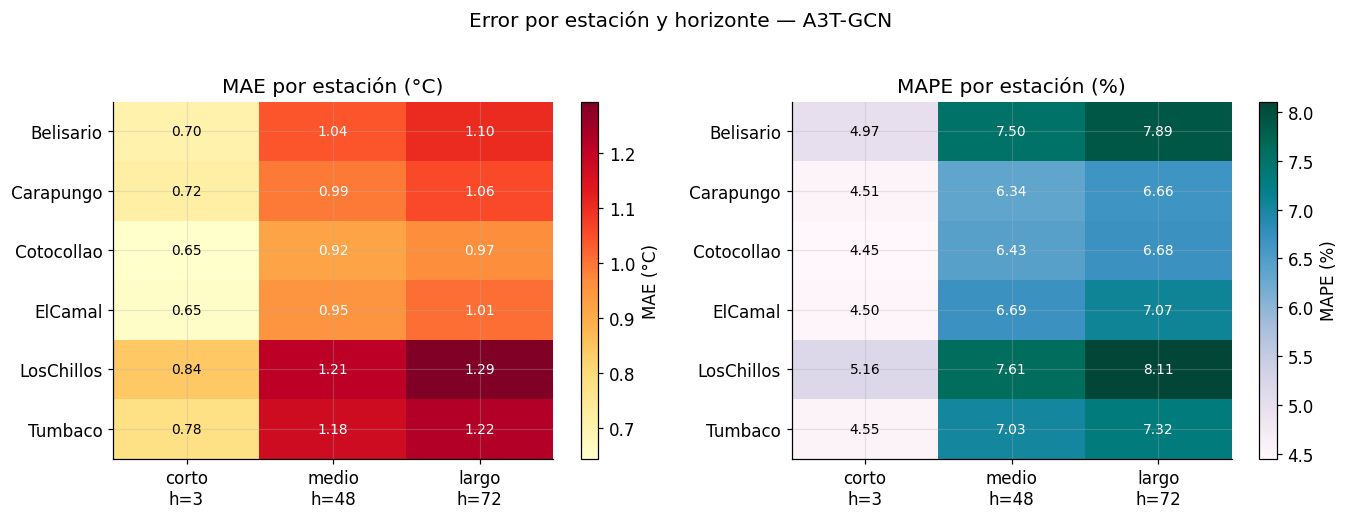

In [7]:
tabla_mape_est = tabla_por_estacion(met_a3t, "MAPE")
paneles = [(tabla_mae_est[ESCENARIOS].values,  "MAE por estación (°C)", "MAE (°C)", "YlOrRd"),
           (tabla_mape_est[ESCENARIOS].values, "MAPE por estación (%)", "MAPE (%)", "PuBuGn")]
xlab = [f"{e}\nh={met_a3t[e]['config']['horizon']}" for e in ESCENARIOS]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
for ax, (data, titulo, cbar, cmap) in zip(axes, paneles):
    im = ax.imshow(data, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(ESCENARIOS))); ax.set_xticklabels(xlab)
    ax.set_yticks(range(len(estaciones))); ax.set_yticklabels(estaciones)
    thr = data.max() * 0.7
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", fontsize=9,
                    color="black" if data[i, j] < thr else "white")
    fig.colorbar(im, ax=ax, label=cbar)
    ax.set_title(titulo)
plt.suptitle("Error por estación y horizonte — A3T-GCN", y=1.02)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "heatmap_mae_mape.png"), bbox_inches="tight")
plt.show()


## 7. Dispersión observado vs predicho (TEST)

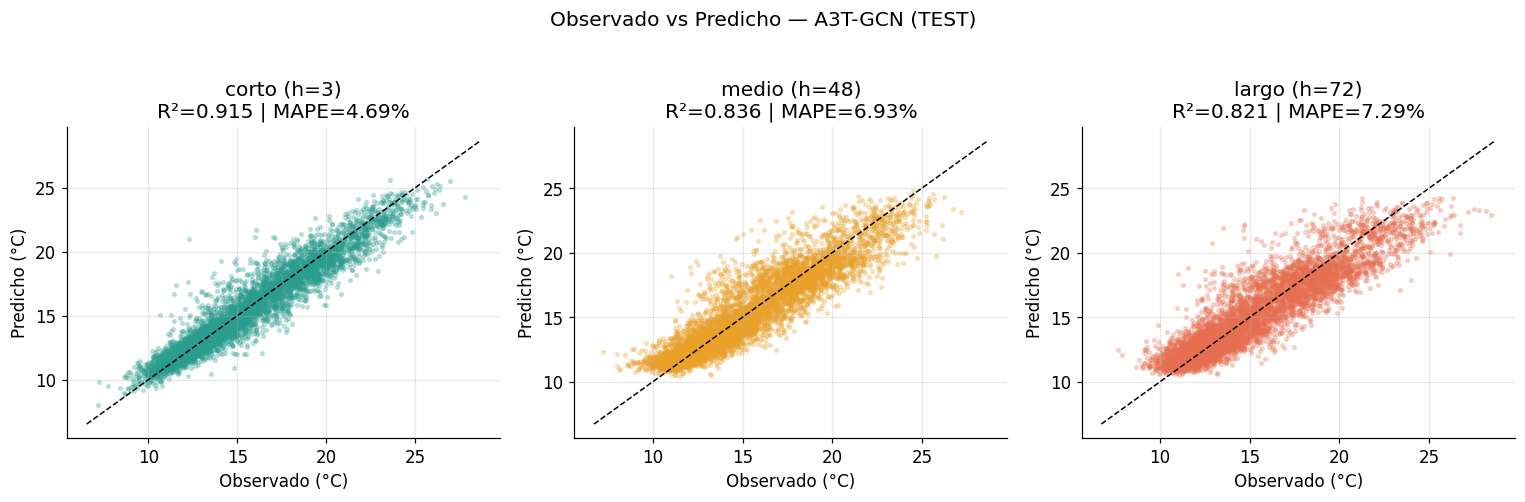

In [8]:
if PREDS_OK:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
    rng = np.random.default_rng(0)
    for ax, esc in zip(axes, ESCENARIOS):
        pred, true, ts, L, h = cargar_preds(RES_A3T, "a3tgcn", esc, met_a3t)
        yt, yp = true.ravel(), pred.ravel()
        idx = rng.choice(len(yt), size=min(6000, len(yt)), replace=False)
        ax.scatter(yt[idx], yp[idx], s=6, alpha=0.25, color=COLORS[esc])
        lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
        ax.plot(lims, lims, "k--", lw=1)
        ax.set_xlabel("Observado (°C)"); ax.set_ylabel("Predicho (°C)")
        ax.set_title(f"{esc} (h={h})\nR²={met_a3t[esc]['global']['R2']:.3f} | "
                     f"MAPE={met_a3t[esc]['global']['MAPE']:.2f}%")
    plt.suptitle("Observado vs Predicho — A3T-GCN (TEST)", y=1.03)
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "scatter_obs_pred.png"), bbox_inches="tight")
    plt.show()
else:
    print("Faltan arrays de predicción; omito la dispersión.")


## 8. Distribución de residuales por horizonte

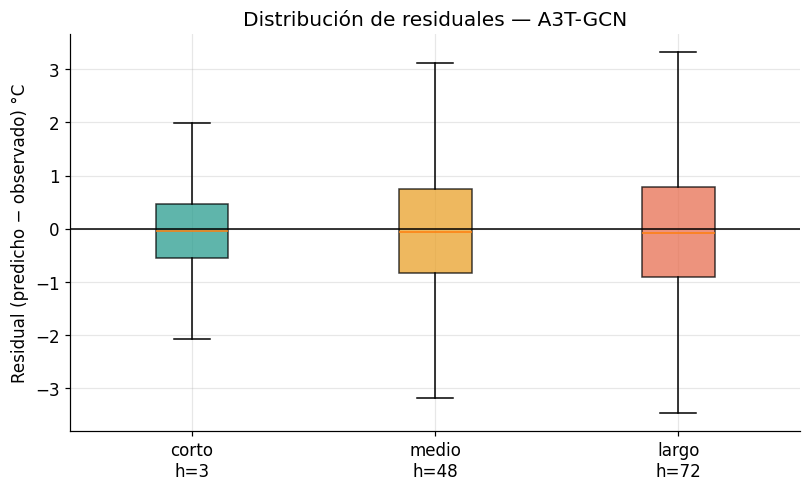

corto  | sesgo medio -0.045 °C | std 1.016 °C
medio  | sesgo medio -0.004 °C | std 1.411 °C
largo  | sesgo medio -0.043 °C | std 1.475 °C


In [9]:
if PREDS_OK:
    res = []
    for esc in ESCENARIOS:
        pred, true, ts, L, h = cargar_preds(RES_A3T, "a3tgcn", esc, met_a3t)
        res.append((pred - true).ravel())
    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    bp = ax.boxplot(res, showfliers=False, patch_artist=True,
                    tick_labels=[f"{e}\nh={met_a3t[e]['config']['horizon']}" for e in ESCENARIOS])
    for patch, esc in zip(bp["boxes"], ESCENARIOS):
        patch.set_facecolor(COLORS[esc]); patch.set_alpha(0.75)
    ax.axhline(0, color="k", lw=1)
    ax.set_ylabel("Residual (predicho − observado) °C")
    ax.set_title("Distribución de residuales — A3T-GCN")
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "residuales.png"), bbox_inches="tight")
    plt.show()
    for esc, r in zip(ESCENARIOS, res):
        print(f"{esc:6s} | sesgo medio {r.mean():+.3f} °C | std {r.std():.3f} °C")
else:
    print("Faltan arrays de predicción; omito residuales.")


## 9. Forecasting — Marzo 2026
Observado vs predicho para cada horizonte. Nota: cada horizonte predice el
mismo instante con distinto *lead time* (3, 48 y 72 h de anticipación).

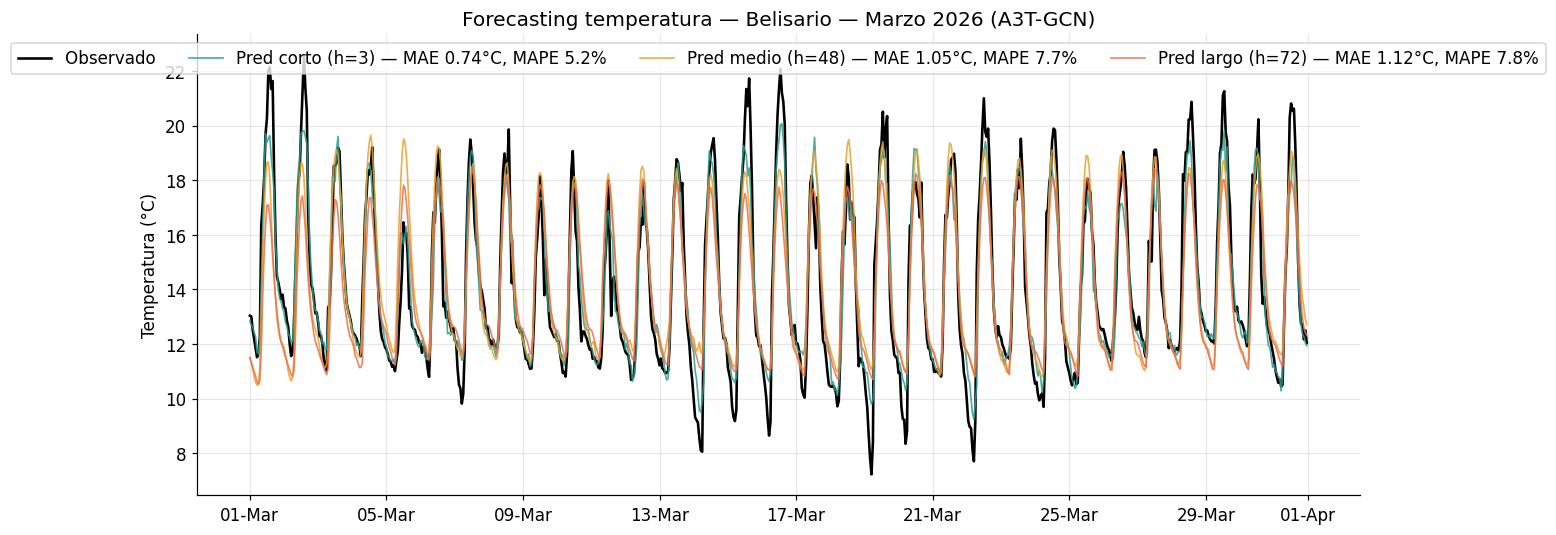

In [10]:
def mascara_mes(ts, y=2026, m=3):
    ini = np.datetime64(f"{y}-{m:02d}-01")
    fin = (np.datetime64(f"{y}-{m+1:02d}-01") if m < 12
           else np.datetime64(f"{y+1}-01-01"))
    return (ts >= ini) & (ts < fin)

if PREDS_OK:
    j = estaciones.index(ESTACION_FORECAST)
    pred_c, true_c, ts_c, _, _ = cargar_preds(RES_A3T, "a3tgcn", "corto", met_a3t)
    m = mascara_mes(ts_c)

    def mape_np(yt, yp, eps=1e-2):
        return float(np.mean(np.abs(yp - yt) / np.maximum(np.abs(yt), eps)) * 100)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(ts_c[m], true_c[m, j], color="black", lw=1.7, label="Observado")
    for esc in ESCENARIOS:
        pred, true, ts, L, h = cargar_preds(RES_A3T, "a3tgcn", esc, met_a3t)
        mm = mascara_mes(ts)
        ytm, ypm = true[mm, j], pred[mm, j]
        maem = float(np.mean(np.abs(ypm - ytm))); mapem = mape_np(ytm, ypm)
        ax.plot(ts[mm], ypm, lw=1.1, alpha=0.85, color=COLORS[esc],
                label=f"Pred {esc} (h={h}) — MAE {maem:.2f}°C, MAPE {mapem:.1f}%")
    ax.set_title(f"Forecasting temperatura — {ESTACION_FORECAST} — Marzo 2026 (A3T-GCN)")
    ax.set_ylabel("Temperatura (°C)"); ax.legend(ncol=4, loc="upper center")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "forecast_marzo2026.png"), bbox_inches="tight")
    plt.show()
else:
    print("Faltan arrays de predicción; omito el forecasting.")


### 9b. Detalle 1–7 de marzo 2026 (zoom)

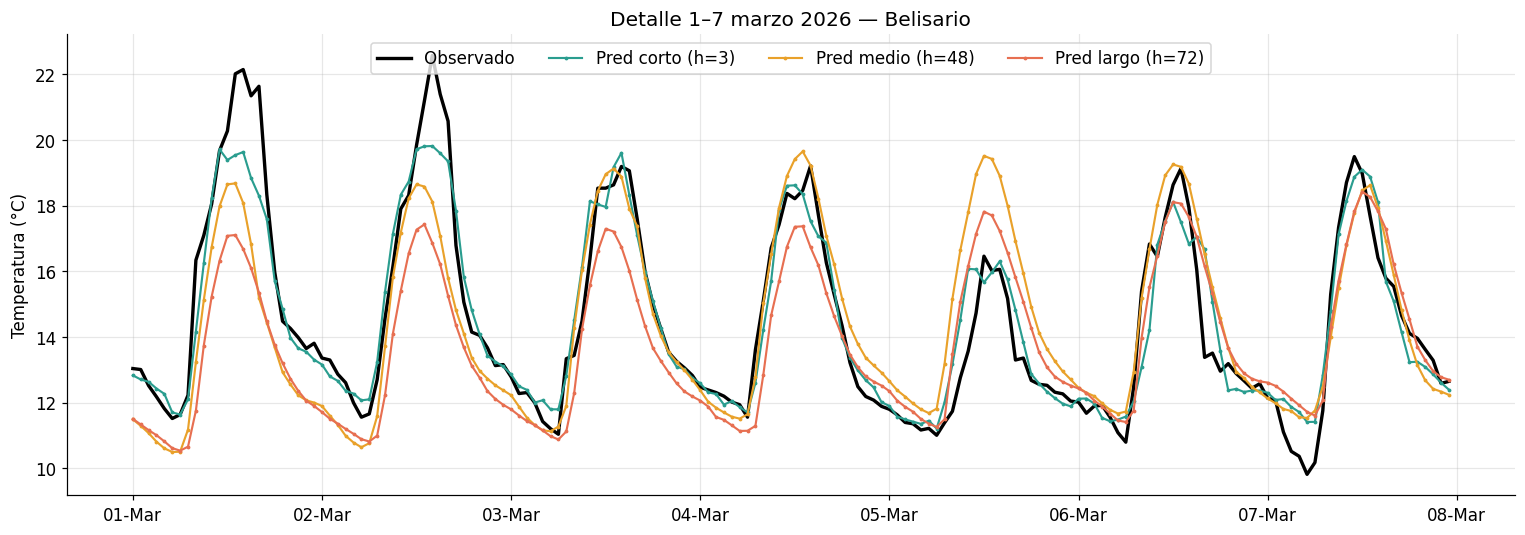

In [11]:
if PREDS_OK:
    z0, z1 = np.datetime64("2026-03-01"), np.datetime64("2026-03-08")
    j = estaciones.index(ESTACION_FORECAST)
    fig, ax = plt.subplots(figsize=(14, 5))
    mz = (ts_c >= z0) & (ts_c < z1)
    ax.plot(ts_c[mz], true_c[mz, j], color="black", lw=2.2, label="Observado")
    for esc in ESCENARIOS:
        pred, true, ts, L, h = cargar_preds(RES_A3T, "a3tgcn", esc, met_a3t)
        mm = (ts >= z0) & (ts < z1)
        ax.plot(ts[mm], pred[mm, j], lw=1.4, marker=".", ms=3,
                color=COLORS[esc], label=f"Pred {esc} (h={h})")
    ax.set_title(f"Detalle 1–7 marzo 2026 — {ESTACION_FORECAST}")
    ax.set_ylabel("Temperatura (°C)"); ax.legend(ncol=4, loc="upper center")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "forecast_marzo2026_zoom.png"), bbox_inches="tight")
    plt.show()


### 9c. Forecasting marzo 2026 — todas las estaciones (horizonte corto)

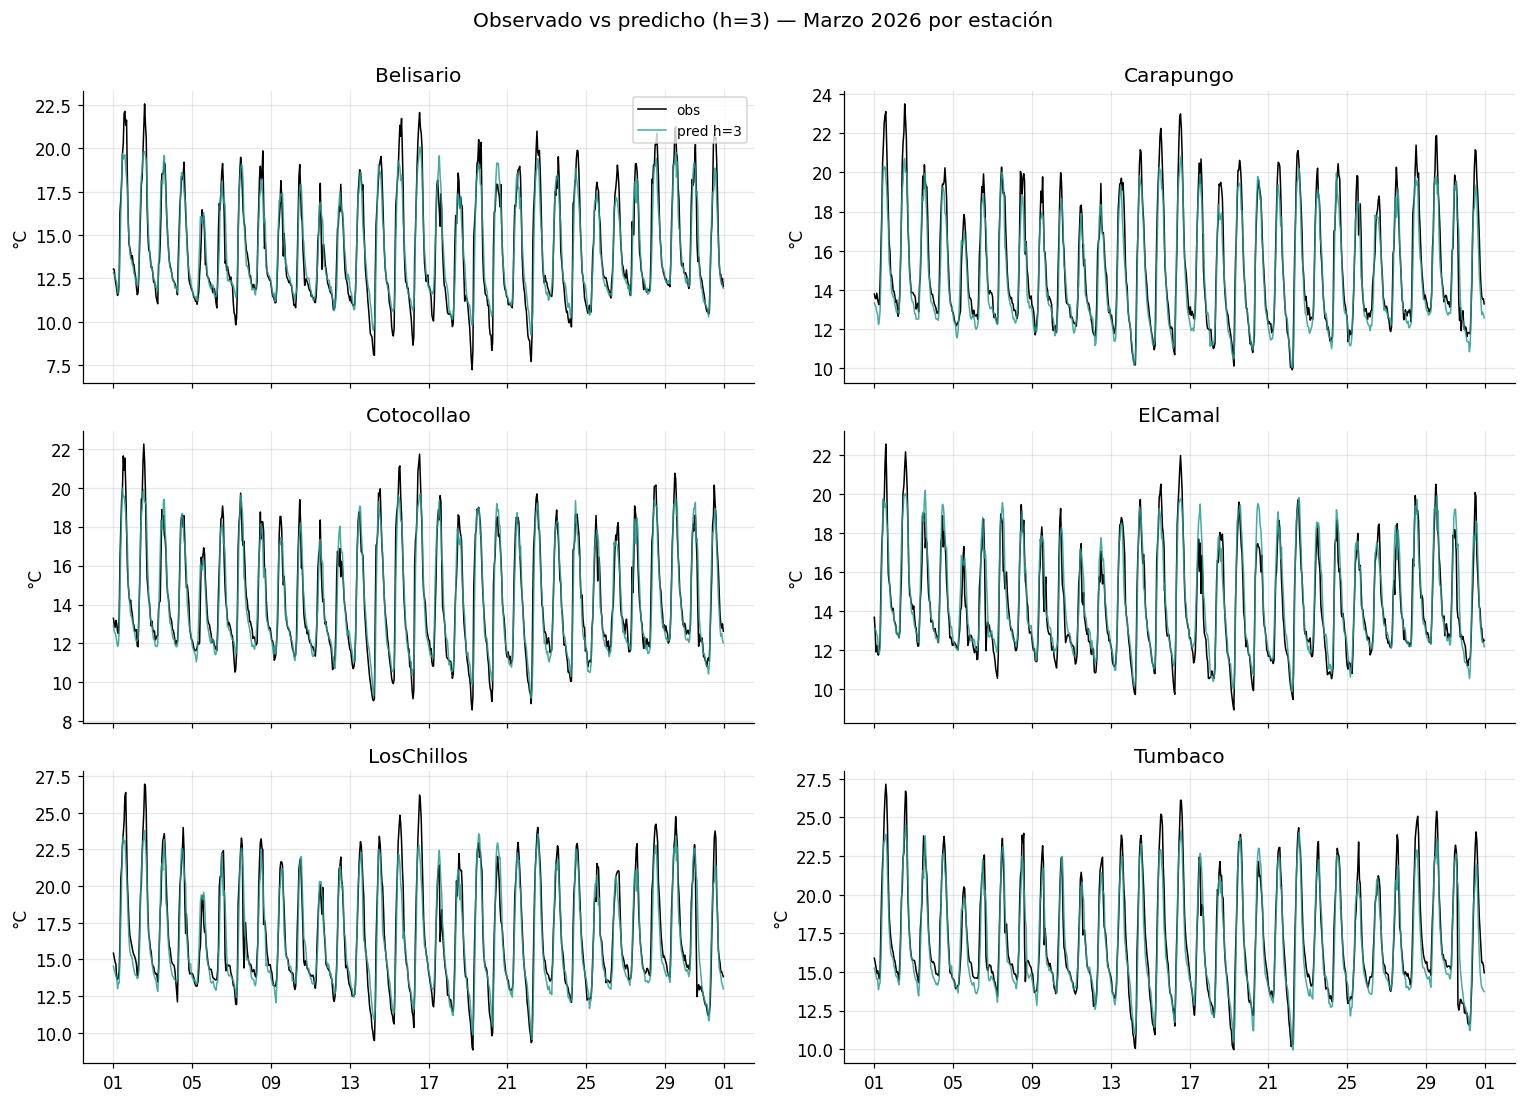

In [12]:
if PREDS_OK:
    pred, true, ts, L, h = cargar_preds(RES_A3T, "a3tgcn", "corto", met_a3t)
    mm = mascara_mes(ts)
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for ax, est in zip(axes.ravel(), estaciones):
        jj = estaciones.index(est)
        ax.plot(ts[mm], true[mm, jj], color="black", lw=1.0, label="obs")
        ax.plot(ts[mm], pred[mm, jj], color=COLORS["corto"], lw=1.0, alpha=0.85,
                label=f"pred h={h}")
        ax.set_title(est); ax.set_ylabel("°C")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d"))
    axes.ravel()[0].legend(loc="upper right", fontsize=9)
    fig.suptitle("Observado vs predicho (h=3) — Marzo 2026 por estación", y=1.0)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "forecast_marzo2026_estaciones.png"), bbox_inches="tight")
    plt.show()


## 10. Comparación A3T-GCN vs DCRNN
Se activa automáticamente cuando exista `resultados/dcrnn/`.

In [13]:
dcrnn_path = os.path.join(RES_DCRNN, "metricas_dcrnn.json")
DCRNN_OK = os.path.exists(dcrnn_path)
if DCRNN_OK:
    met_d = cargar_json(dcrnn_path)
    PREDS_DCRNN_OK = all(
        os.path.exists(os.path.join(RES_DCRNN,
            f"dcrnn_{e}_h{met_d[e]['config']['horizon']}_pred_test.npy"))
        for e in ESCENARIOS)
    print("DCRNN métricas: OK | arrays de predicción DCRNN:", PREDS_DCRNN_OK)
else:
    print("DCRNN aún no disponible. Corre entrenar_dcrnn.py y re-ejecuta desde aquí.")


DCRNN métricas: OK | arrays de predicción DCRNN: True


### 10a. Comparación en las 4 métricas (MAE, RMSE, R², MAPE)

MAE    RMSE      R2    MAPE
escenario modelo                                 
corto     A3T-GCN  0.7233  1.0166  0.9147  4.6897
          DCRNN    0.6573  0.9458  0.9262  4.2662
medio     A3T-GCN  1.0484  1.4110  0.8360  6.9318
          DCRNN    1.0401  1.4054  0.8373  6.8815
largo     A3T-GCN  1.1085  1.4758  0.8207  7.2876
          DCRNN    1.0940  1.4536  0.8261  7.1646

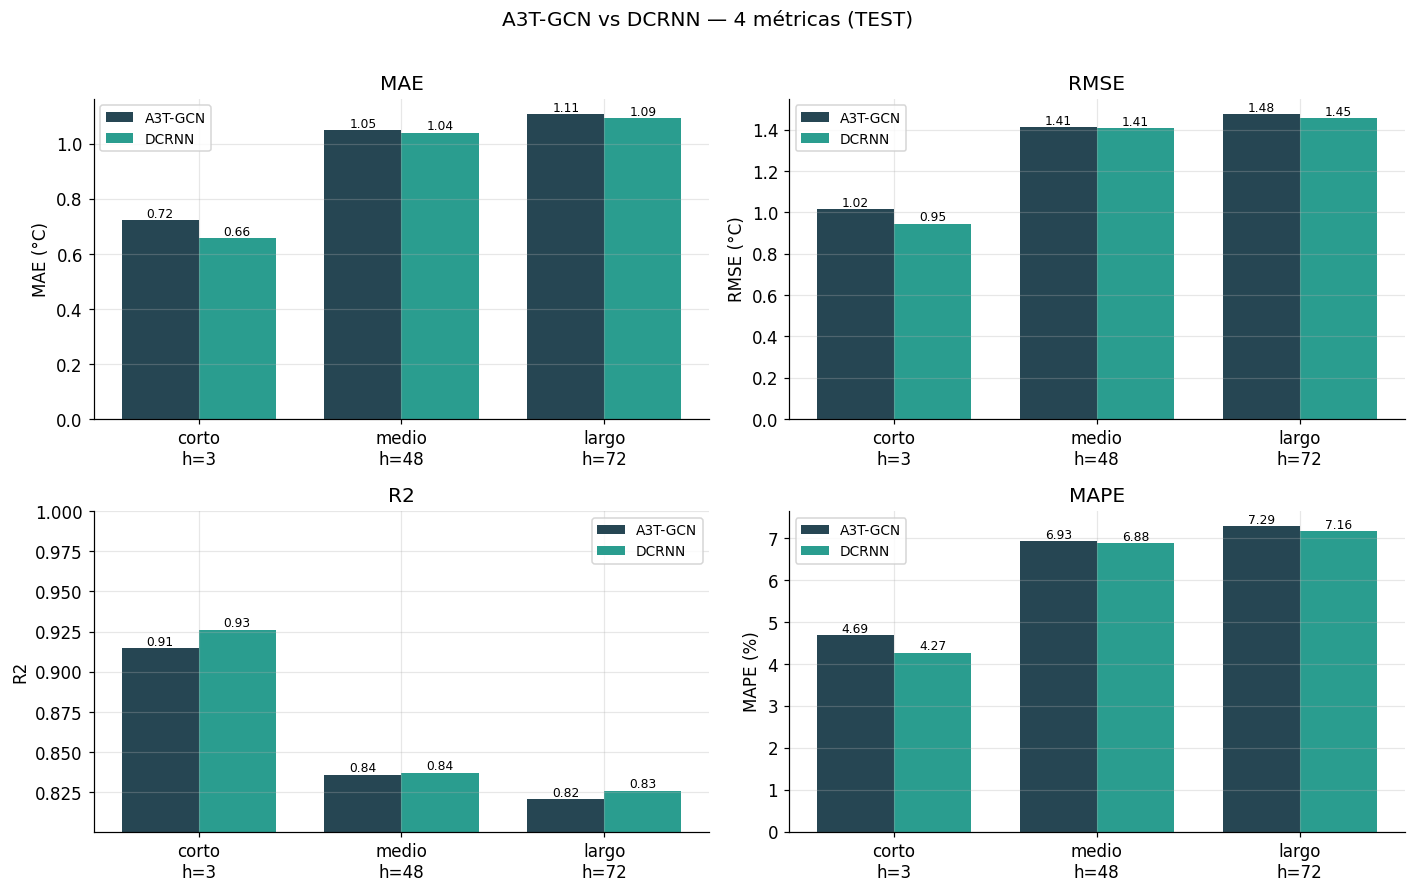

In [14]:
if DCRNN_OK:
    METRICAS = ["MAE", "RMSE", "R2", "MAPE"]
    UNID = {"MAE": "°C", "RMSE": "°C", "R2": "", "MAPE": "%"}

    reg = []
    for e in ESCENARIOS:
        for modelo, met in [("A3T-GCN", met_a3t), ("DCRNN", met_d)]:
            fila = {"escenario": e, "modelo": modelo}
            fila.update({m: met[e]["global"][m] for m in METRICAS})
            reg.append(fila)
    tabla_comp = pd.DataFrame(reg).set_index(["escenario", "modelo"]).round(4)
    display(tabla_comp)
    tabla_comp.to_csv(os.path.join(FIG_DIR, "comparativa_global.csv"))

    x = np.arange(len(ESCENARIOS)); w = 0.38
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    for ax, m in zip(axes.ravel(), METRICAS):
        va = [met_a3t[e]["global"][m] for e in ESCENARIOS]
        vd = [met_d[e]["global"][m] for e in ESCENARIOS]
        ax.bar(x - w/2, va, w, label="A3T-GCN", color="#264653")
        ax.bar(x + w/2, vd, w, label="DCRNN", color="#2a9d8f")
        ax.set_xticks(x)
        ax.set_xticklabels([f"{e}\nh={met_a3t[e]['config']['horizon']}" for e in ESCENARIOS])
        u = UNID[m]; ax.set_ylabel(f"{m} ({u})" if u else m); ax.set_title(m)
        for xi, (a, d) in enumerate(zip(va, vd)):
            ax.text(xi - w/2, a, f"{a:.2f}", ha="center", va="bottom", fontsize=8)
            ax.text(xi + w/2, d, f"{d:.2f}", ha="center", va="bottom", fontsize=8)
        if m == "R2":                       # acotar para ver diferencias finas
            ax.set_ylim(min(min(va), min(vd)) - 0.02, 1.0)
        ax.legend(fontsize=9)
    plt.suptitle("A3T-GCN vs DCRNN — 4 métricas (TEST)", y=1.01)
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "comparativa_4metricas.png"), bbox_inches="tight")
    plt.show()


### 10b. Mejora relativa de DCRNN sobre A3T-GCN (MAE)
`(MAE_A3T − MAE_DCRNN) / MAE_A3T × 100`.  Positivo (azul) = DCRNN mejor.

Mejora % de DCRNN sobre A3T-GCN en MAE (+ = DCRNN mejor):


,corto,medio,largo
Belisario,6.57,-0.06,1.92
Carapungo,13.08,3.01,2.73
Cotocollao,5.05,0.02,0.87
ElCamal,7.54,-0.01,0.82
LosChillos,10.90,-0.03,1.97
Tumbaco,10.62,1.81,-0.39


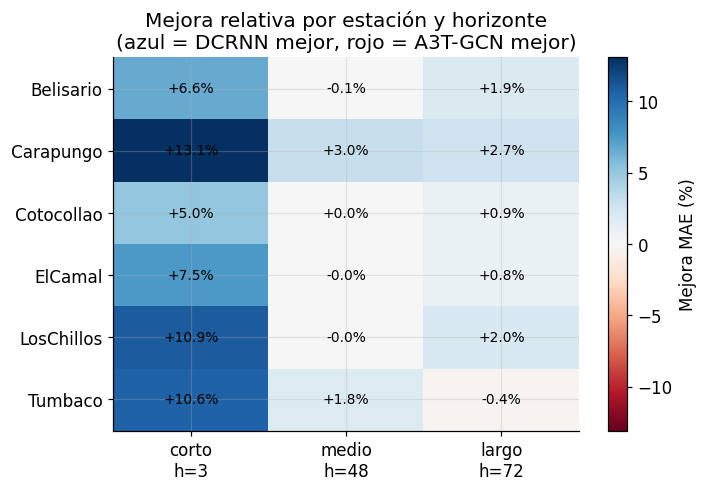

In [15]:
if DCRNN_OK:
    filas = {}
    for e in ESCENARIOS:
        col = {}
        for est in estaciones:
            a = met_a3t[e]["por_estacion"][est]["MAE"]
            d = met_d[e]["por_estacion"][est]["MAE"]
            col[est] = (a - d) / a * 100
        filas[e] = col
    mejora = pd.DataFrame(filas)[ESCENARIOS].round(2)
    print("Mejora % de DCRNN sobre A3T-GCN en MAE (+ = DCRNN mejor):")
    display(mejora)
    mejora.to_csv(os.path.join(FIG_DIR, "mejora_relativa_mae.csv"))

    data = mejora.values
    vmax = max(np.abs(data).max(), 1e-6)
    fig, ax = plt.subplots(figsize=(6.6, 4.6))
    im = ax.imshow(data, aspect="auto", cmap="RdBu", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(ESCENARIOS)))
    ax.set_xticklabels([f"{e}\nh={met_a3t[e]['config']['horizon']}" for e in ESCENARIOS])
    ax.set_yticks(range(len(estaciones))); ax.set_yticklabels(estaciones)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i, j]:+.1f}%", ha="center", va="center", fontsize=9)
    fig.colorbar(im, label="Mejora MAE (%)")
    ax.set_title("Mejora relativa por estación y horizonte\n(azul = DCRNN mejor, rojo = A3T-GCN mejor)")
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "mejora_relativa.png"), bbox_inches="tight")
    plt.show()


### 10c. Forecasting marzo 2026 — A3T-GCN vs DCRNN

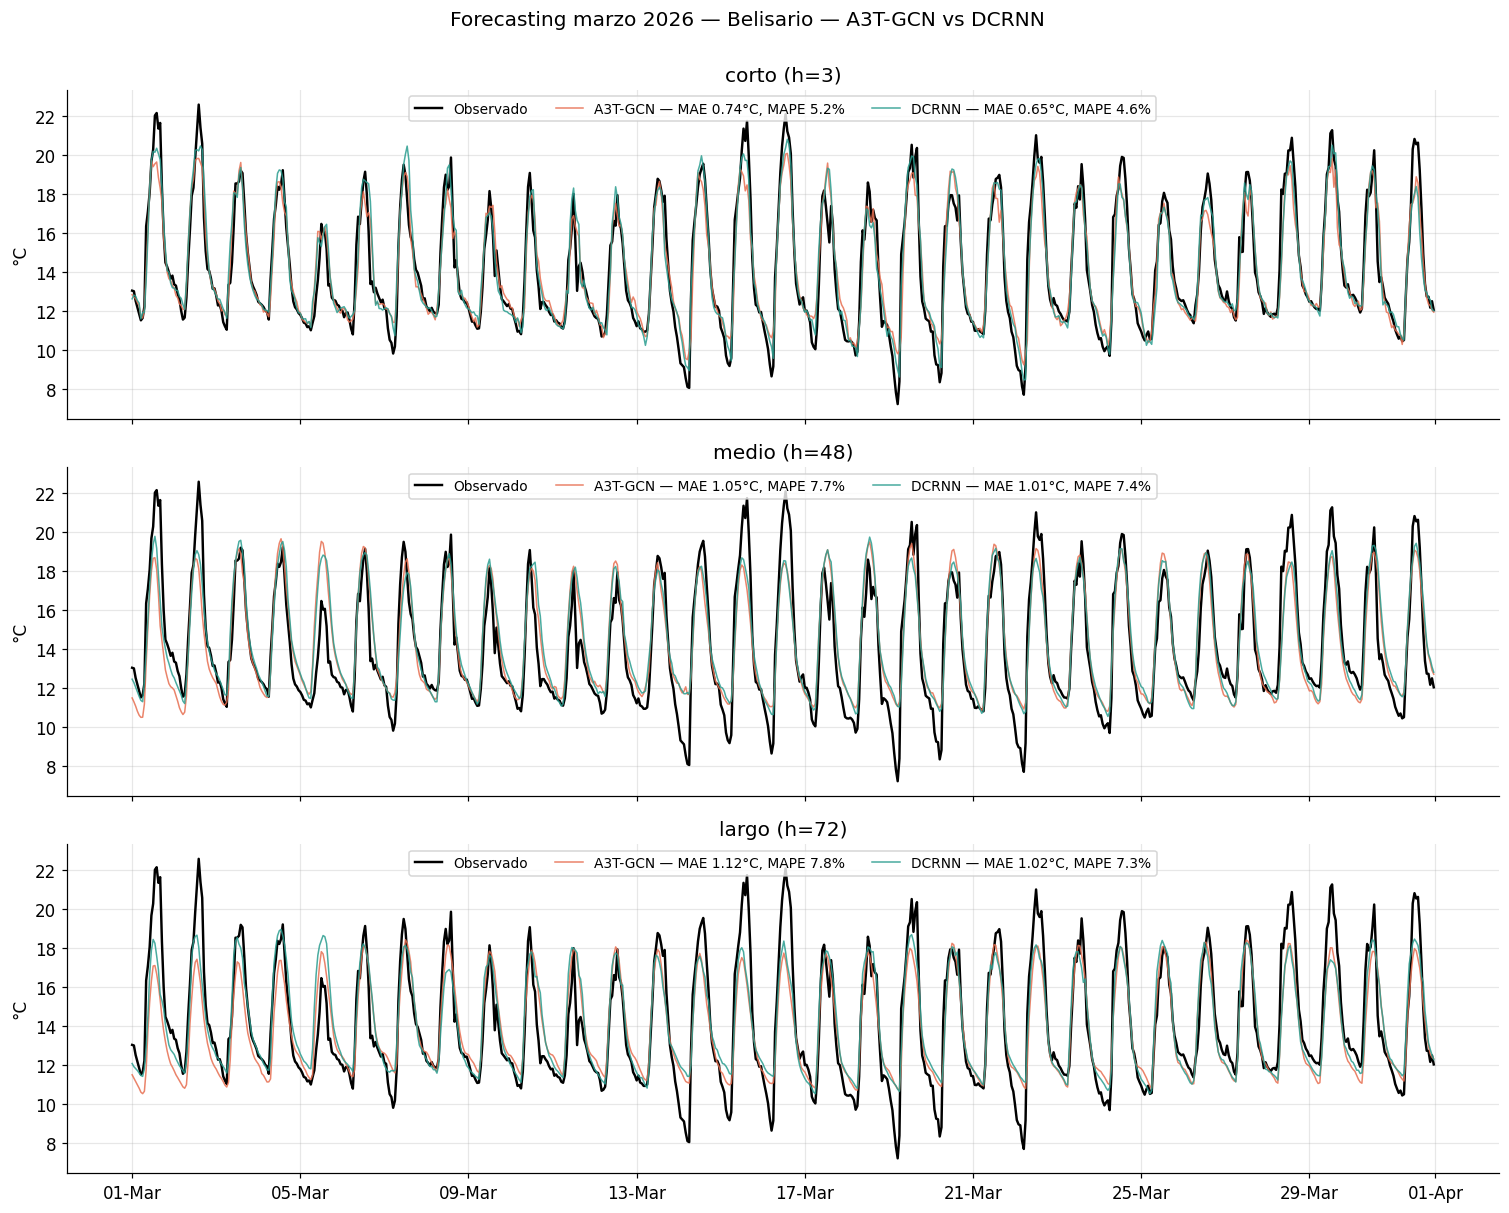

In [16]:
if DCRNN_OK and PREDS_OK and PREDS_DCRNN_OK:
    def mape_np(yt, yp, eps=1e-2):
        return float(np.mean(np.abs(yp - yt) / np.maximum(np.abs(yt), eps)) * 100)

    j = estaciones.index(ESTACION_FORECAST)
    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
    for ax, esc in zip(axes, ESCENARIOS):
        pa, ta, tsa, L, h = cargar_preds(RES_A3T, "a3tgcn", esc, met_a3t)
        pd_, td_, tsd, _, _ = cargar_preds(RES_DCRNN, "dcrnn", esc, met_d)
        ma, mdd = mascara_mes(tsa), mascara_mes(tsd)
        maea = float(np.mean(np.abs(pa[ma, j] - ta[ma, j]))); mapea = mape_np(ta[ma, j], pa[ma, j])
        maed = float(np.mean(np.abs(pd_[mdd, j] - td_[mdd, j]))); maped = mape_np(td_[mdd, j], pd_[mdd, j])
        ax.plot(tsa[ma], ta[ma, j], color="black", lw=1.6, label="Observado")
        ax.plot(tsa[ma], pa[ma, j], color="#e76f51", lw=1.0, alpha=0.85,
                label=f"A3T-GCN — MAE {maea:.2f}°C, MAPE {mapea:.1f}%")
        ax.plot(tsd[mdd], pd_[mdd, j], color="#2a9d8f", lw=1.0, alpha=0.85,
                label=f"DCRNN — MAE {maed:.2f}°C, MAPE {maped:.1f}%")
        ax.set_title(f"{esc} (h={h})"); ax.set_ylabel("°C")
        ax.legend(loc="upper center", ncol=3, fontsize=9)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
    fig.suptitle(f"Forecasting marzo 2026 — {ESTACION_FORECAST} — A3T-GCN vs DCRNN", y=1.0)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "forecast_marzo2026_comparativa.png"), bbox_inches="tight")
    plt.show()
else:
    print("Faltan arrays de predicción (A3T-GCN y/o DCRNN) para el forecasting comparativo.")


## 11. Lectura de resultados
- El error crece con el horizonte (degradación esperada); revisa si el salto
  grande ocurre de *corto* a *medio* y luego se aplana (dominio del ciclo diurno).
- Estaciones de valle (Los Chillos, Tumbaco) suelen tener mayor MAE por su
  microclima; el R² se mantiene alto porque tienen mayor varianza diurna.
- Todas las figuras y tablas se guardan en `resultados/figuras/`.
